In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_csv("cleaned_superstore.csv")

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,profit,shipping_cost,order_priority,year,month,month_name,day,day_name,quarter,delivery_days
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,106.140,35.46,Medium,2011,1,January,1,Saturday,1,5
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,36.036,9.72,Medium,2011,1,January,1,Saturday,1,7
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,29.640,8.17,High,2011,1,January,1,Saturday,1,4
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,-26.055,4.82,High,2011,1,January,1,Saturday,1,4
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,37.770,4.70,Medium,2011,1,January,1,Saturday,1,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [ ]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
# Profit Margin
df["profit_margin"] = (df["profit"] / df["sales"]) * 100
df["profit_margin"] = df["profit_margin"].round(2)
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,shipping_cost,order_priority,year,month,month_name,day,day_name,quarter,delivery_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,35.46,Medium,2011,1,January,1,Saturday,1,5,26.01
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,9.72,Medium,2011,1,January,1,Saturday,1,7,30.03
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,8.17,High,2011,1,January,1,Saturday,1,4,44.91
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,4.82,High,2011,1,January,1,Saturday,1,4,-57.90
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,4.70,Medium,2011,1,January,1,Saturday,1,7,33.13


In [ ]:
# Average Selling Price

df["average_selling_price"] = df["sales"] / df["quantity"]

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,order_priority,year,month,month_name,day,day_name,quarter,delivery_days,profit_margin,average_selling_price
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Medium,2011,1,January,1,Saturday,1,5,26.01,204.0
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Medium,2011,1,January,1,Saturday,1,7,30.03,40.0
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,High,2011,1,January,1,Saturday,1,4,44.91,16.5
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,High,2011,1,January,1,Saturday,1,4,-57.90,15.0
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Medium,2011,1,January,1,Saturday,1,7,33.13,22.8


In [ ]:
# Delivery Time Category

def delivery_category(days):

    if days <= 3:
        return "Fast"

    elif days <= 6:
        return "Medium"

    else:
        return "Slow"

In [ ]:
df["delivery_category"] = df["delivery_days"].apply(delivery_category)

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,year,month,month_name,day,day_name,quarter,delivery_days,profit_margin,average_selling_price,delivery_category
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,2011,1,January,1,Saturday,1,5,26.01,204.0,Medium
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,2011,1,January,1,Saturday,1,7,30.03,40.0,Slow
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,2011,1,January,1,Saturday,1,4,44.91,16.5,Medium
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,2011,1,January,1,Saturday,1,4,-57.90,15.0,Medium
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,2011,1,January,1,Saturday,1,7,33.13,22.8,Slow


In [ ]:
# Discount Category

def discount_type(discount):

    if discount == 0:
        return "No Discount"

    elif discount <= 0.2:
        return "Low"

    elif discount <= 0.5:
        return "Medium"

    else:
        return "High"

In [ ]:
df["discount_category"] = df["discount"].apply(discount_type)

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,month,month_name,day,day_name,quarter,delivery_days,profit_margin,average_selling_price,delivery_category,discount_category
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,1,January,1,Saturday,1,5,26.01,204.0,Medium,No Discount
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,1,January,1,Saturday,1,7,30.03,40.0,Slow,Low
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,1,January,1,Saturday,1,4,44.91,16.5,Medium,No Discount
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,1,January,1,Saturday,1,4,-57.90,15.0,Medium,Medium
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,1,January,1,Saturday,1,7,33.13,22.8,Slow,Low


In [ ]:
# Sales Category

def sales_bucket(sales):

    if sales < 100:
        return "Low"

    elif sales < 500:
        return "Medium"

    else:
        return "High"

In [ ]:
df["sales_category"] = df["sales"].apply(sales_bucket)

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,month_name,day,day_name,quarter,delivery_days,profit_margin,average_selling_price,delivery_category,discount_category,sales_category
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,January,1,Saturday,1,5,26.01,204.0,Medium,No Discount,Medium
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,January,1,Saturday,1,7,30.03,40.0,Slow,Low,Medium
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,January,1,Saturday,1,4,44.91,16.5,Medium,No Discount,Low
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,January,1,Saturday,1,4,-57.90,15.0,Medium,Medium,Low
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,January,1,Saturday,1,7,33.13,22.8,Slow,Low,Medium


In [ ]:
# High Profit Product

average_profit = df["profit"].mean()

df["high_profit"] = np.where(
    df["profit"] > average_profit,
    1,
    0
)

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,day,day_name,quarter,delivery_days,profit_margin,average_selling_price,delivery_category,discount_category,sales_category,high_profit
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,1,Saturday,1,5,26.01,204.0,Medium,No Discount,Medium,1
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,1,Saturday,1,7,30.03,40.0,Slow,Low,Medium,1
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,1,Saturday,1,4,44.91,16.5,Medium,No Discount,Low,1
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,1,Saturday,1,4,-57.90,15.0,Medium,Medium,Low,0
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,1,Saturday,1,7,33.13,22.8,Slow,Low,Medium,1


In [ ]:
#Order Value

df["order_value"] = df["sales"] * df["quantity"]

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,day_name,quarter,delivery_days,profit_margin,average_selling_price,delivery_category,discount_category,sales_category,high_profit,order_value
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Saturday,1,5,26.01,204.0,Medium,No Discount,Medium,1,816.0
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Saturday,1,7,30.03,40.0,Slow,Low,Medium,1,360.0
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Saturday,1,4,44.91,16.5,Medium,No Discount,Low,1,264.0
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Saturday,1,4,-57.90,15.0,Medium,Medium,Low,0,135.0
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Saturday,1,7,33.13,22.8,Slow,Low,Medium,1,570.0


In [ ]:
# Shipping Cost Percentage

df["shipping_percentage"] = (
    df["shipping_cost"] /
    df["sales"]
) * 100

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,quarter,delivery_days,profit_margin,average_selling_price,delivery_category,discount_category,sales_category,high_profit,order_value,shipping_percentage
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,1,5,26.01,204.0,Medium,No Discount,Medium,1,816.0,8.691176
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,1,7,30.03,40.0,Slow,Low,Medium,1,360.0,8.100000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,1,4,44.91,16.5,Medium,No Discount,Low,1,264.0,12.378788
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,1,4,-57.90,15.0,Medium,Medium,Low,0,135.0,10.711111
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,1,7,33.13,22.8,Slow,Low,Medium,1,570.0,4.122807


In [ ]:
# Encode Category

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["category_encoded"] = encoder.fit_transform(df["category"])

In [ ]:
# Encode Sub Category

df["sub_category_encoded"] = encoder.fit_transform(df["sub_category"])

In [ ]:
# Encode Region

df["region_encoded"] = encoder.fit_transform(df["region"])

In [ ]:
# Encode Market

df["market_encoded"] = encoder.fit_transform(df["market"])

In [ ]:
# Encode Segment

df["segment_encoded"] = encoder.fit_transform(df["segment"])

In [ ]:
# Encode Ship Mode

df["ship_mode_encoded"] = encoder.fit_transform(df["ship_mode"])

In [ ]:
# Feature Correlation

numeric = df.select_dtypes(include=np.number)

numeric.corr()

,sales,quantity,discount,profit,shipping_cost,year,month,day,quarter,delivery_days,...,average_selling_price,high_profit,order_value,shipping_percentage,category_encoded,sub_category_encoded,region_encoded,market_encoded,segment_encoded,ship_mode_encoded
sales,1.000000,0.276072,-0.106719,0.252703,0.771133,-0.002479,0.005302,-0.000775,0.006465,0.001164,...,0.747514,0.518799,0.830915,-0.001033,0.035972,0.029632,0.040607,-0.055063,-0.002602,0.005186
quantity,0.276072,1.000000,-0.019875,0.104743,0.272649,-0.005049,0.020611,0.004509,0.022496,0.004347,...,-0.162090,0.239520,0.583108,-0.008671,-0.009578,0.003890,0.127454,0.077911,0.001593,0.004688
discount,-0.106719,-0.019875,1.000000,-0.316375,-0.079056,-0.005894,0.000027,-0.006320,0.000466,-0.001507,...,-0.120082,-0.321208,-0.066909,-0.001358,-0.047841,0.004928,0.028198,-0.017332,-0.004460,-0.009721
profit,0.252703,0.104743,-0.316375,1.000000,0.357033,0.002661,-0.000156,-0.002629,0.000190,0.001543,...,0.241903,0.423238,0.174415,0.005715,0.066100,-0.040393,0.003468,-0.017566,0.002873,0.002481
shipping_cost,0.771133,0.272649,-0.079056,0.357033,1.000000,-0.003136,0.004929,0.005266,0.005971,-0.142823,...,0.586124,0.362502,0.634062,0.394193,0.032541,0.012232,0.035168,-0.050281,0.000334,-0.145188
year,-0.002479,-0.005049,-0.005894,0.002661,-0.003136,1.000000,-0.014193,0.004107,-0.011695,-0.003427,...,0.005198,-0.001390,-0.008304,-0.007059,-0.001533,-0.004701,-0.011830,-0.014387,0.018700,-0.001809
month,0.005302,0.020611,0.000027,-0.000156,0.004929,-0.014193,1.000000,0.003281,0.970096,0.005268,...,-0.001205,0.004155,0.007376,-0.001808,-0.005585,-0.003243,0.021154,0.056577,-0.011364,0.004049
day,-0.000775,0.004509,-0.006320,-0.002629,0.005266,0.004107,0.003281,1.000000,0.004739,0.001393,...,-0.003696,0.006302,0.000048,-0.006529,-0.007424,0.012557,0.005051,-0.004482,0.003826,0.002229
quarter,0.006465,0.022496,0.000466,0.000190,0.005971,-0.011695,0.970096,0.004739,1.000000,0.005829,...,-0.001496,0.004044,0.008437,-0.001098,-0.004925,-0.002120,0.024441,0.052487,-0.009028,0.003330
delivery_days,0.001164,0.004347,-0.001507,0.001543,-0.142823,-0.003427,0.005268,0.001393,0.005829,1.000000,...,-0.002228,-0.000222,0.001655,-0.481342,-0.003734,0.001877,-0.002431,0.006612,0.006635,0.719340


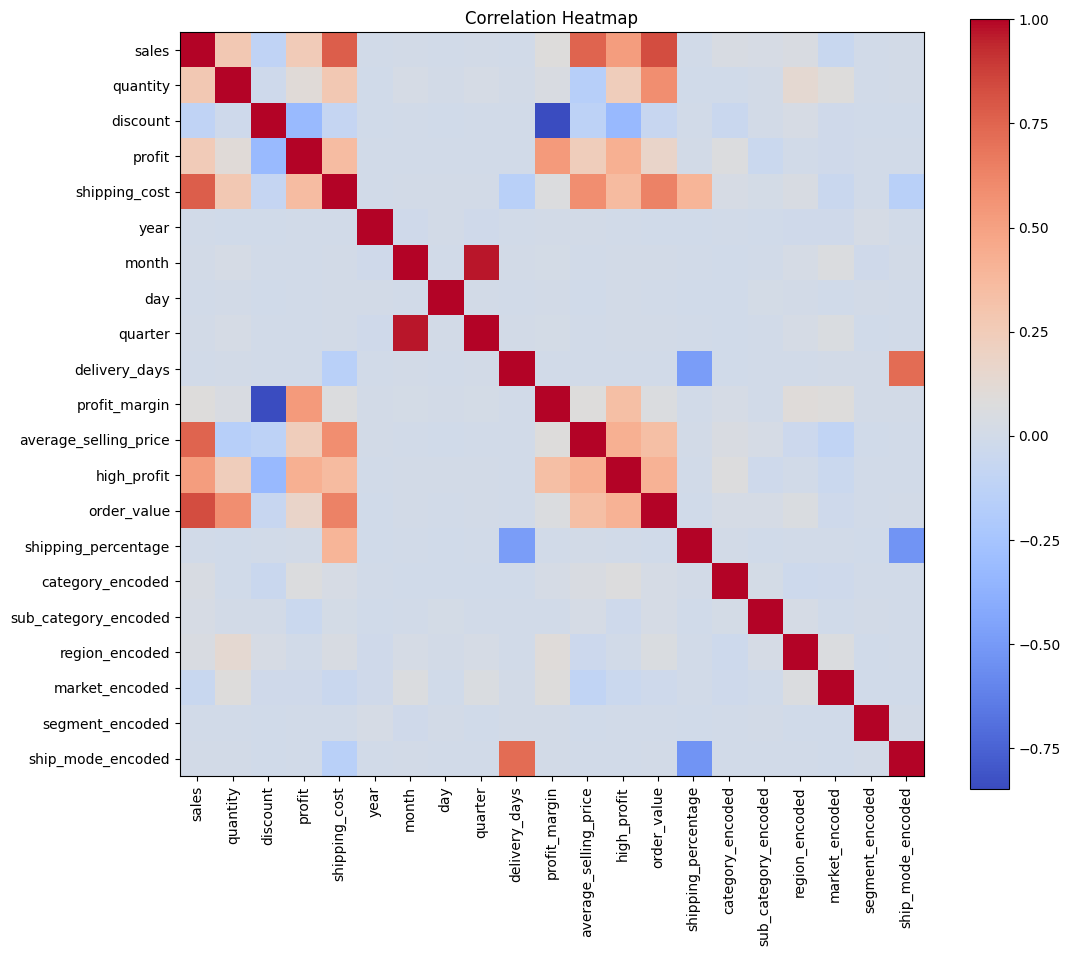

In [ ]:
# Correlation Heatmap

import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.imshow(numeric.corr(), cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(numeric.columns)),
    numeric.columns,
    rotation=90
)

plt.yticks(
    range(len(numeric.columns)),
    numeric.columns
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Final Dataset

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sales_category,high_profit,order_value,shipping_percentage,category_encoded,sub_category_encoded,region_encoded,market_encoded,segment_encoded,ship_mode_encoded
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Medium,1,816.0,8.691176,1,14,0,1,0,3
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Medium,1,360.0,8.100000,1,15,9,0,0,3
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Low,1,264.0,12.378788,1,14,5,3,0,2
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Low,0,135.0,10.711111,1,12,7,4,2,2
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Medium,1,570.0,4.122807,0,9,9,0,0,3


In [ ]:
# Dataset Shape

df.shape

(51290, 41)

In [ ]:
# Save Feature Engineered Dataset

df.to_csv(
    "feature_engineered_superstore.csv",
    index=False
)

print("Feature Engineered Dataset Saved Successfully.")

Feature Engineered Dataset Saved Successfully.


In [ ]:
from google.colab import files

files.download("feature_engineered_superstore.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>